# Classifying Breast Tumors -- SVM Model

This notebook trains a Support Vector Machine (RBF kernel) on a binary classification
task, evaluates it with 5-fold stratified cross-validation, and reports final
performance on a held-out test set.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix, 
    ConfusionMatrixDisplay
)

## Load Data

In [ ]:
training_df = pd.read_csv("../../data/processed/development_unscaled.csv")
testing_df = pd.read_csv("../../data/processed/test_unscaled_FINAL_HOLDOUT.csv")

# Split into features (X) and labels (y); map label 0 -> -1 for SVM convention
X = training_df.iloc[:, 1:-1]
y = np.where(training_df.iloc[:, -1] == 0, -1, 1)

X_test = testing_df.iloc[:, 1:-1]
y_test = np.where(testing_df.iloc[:, -1] == 0, -1, 1)

## 5-Fold Stratified Cross-Validation

Each fold is scaled independently (fit on the training split, applied to the
validation split) to avoid data leakage.

In [11]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for fold, (train_index, valid_index) in enumerate(skf.split(X, y), start=1):

    X_train_fold = X.iloc[train_index]
    X_valid_fold = X.iloc[valid_index]

    y_train_fold = y[train_index]
    y_valid_fold = y[valid_index]

    # Scaling
    scaler = MinMaxScaler()

    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_valid_scaled = scaler.transform(X_valid_fold)

    # Hand-tuned SVM
    model = SVC(
        C=1,
        kernel="rbf",
        gamma=0.67
    )

    model.fit(X_train_scaled, y_train_fold)

    # Predictions on validation fold
    predictions = model.predict(X_valid_scaled)

    # Decision scores for ROC-AUC
    scores = model.decision_function(X_valid_scaled)

    cv_results.append({
        "fold": fold,
        "accuracy": accuracy_score(y_valid_fold, predictions),
        "precision": precision_score(y_valid_fold, predictions),
        "recall": recall_score(y_valid_fold, predictions),
        "f1": f1_score(y_valid_fold, predictions),
        "roc_auc": roc_auc_score(y_valid_fold, scores),
    })


cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

print("\nMean cross-validation results:")

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    mean_value = cv_results_df[metric].mean()
    std_value = cv_results_df[metric].std()

    print(f"{metric.capitalize()}: {mean_value:.4f} ± {std_value:.4f}")

,fold,accuracy,precision,recall,f1,roc_auc
0,1,0.967033,1.000000,0.911765,0.953846,0.996904
1,2,0.978022,0.944444,1.000000,0.971429,0.999484
2,3,0.967033,1.000000,0.911765,0.953846,0.997420
3,4,0.967033,1.000000,0.911765,0.953846,0.980908
4,5,0.989011,1.000000,0.970588,0.985075,0.995872



Mean cross-validation results:
Accuracy: 0.9736 ± 0.0098
Precision: 0.9889 ± 0.0248
Recall: 0.9412 ± 0.0416
F1: 0.9636 ± 0.0142
Roc_auc: 0.9941 ± 0.0075


## Final Model — Held-Out Test Set

Refit on the full development set, then evaluate once on the untouched holdout set.

In [12]:
scaler = MinMaxScaler()

feature_names = X.columns

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=feature_names
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)

model = SVC(C=1, kernel="rbf", gamma=0.67)
model.fit(X_train_scaled, y)

param_grid = {
        'C': [0.1, 1, 10, 100],
        'kernel': ['rbf'],
        'gamma': ['scale', 'auto'],
    }
test_predictions = model.predict(X_test_scaled)
test_scores = model.decision_function(X_test_scaled)

print(f"""
Hold Out Test Metrics:
    Accuracy:  {accuracy_score(y_test, test_predictions):.4f}
    Precision: {precision_score(y_test, test_predictions):.4f}
    Recall:    {recall_score(y_test, test_predictions):.4f}
    F1:        {f1_score(y_test, test_predictions):.4f}
    ROC AUC:   {roc_auc_score(y_test, test_scores):.4f}
""")


# Create GridSearchCV object
grid_search_svm = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)
param_grid = {
        'C': [0.1, 0.5, 1, 1.5],
        'kernel': ['rbf'],
        'gamma': ['scale', 'auto'],
    }

# Fit GridSearchCV on training data
grid_search_svm.fit(X_train_scaled, y)

# Best SVM model
model = grid_search_svm.best_estimator_
predictions = model.predict(X_valid_scaled)
model.fit(X_train_scaled, y)

test_predictions = model.predict(X_test_scaled)



print(f"""
Hold Out Test Metrics:
    Accuracy:  {accuracy_score(y_test, test_predictions):.4f}
    Precision: {precision_score(y_test, test_predictions):.4f}
    Recall:    {recall_score(y_test, test_predictions):.4f}
    F1:        {f1_score(y_test, test_predictions):.4f}
    ROC AUC:   {roc_auc_score(y_test, test_scores):.4f}
""")


Hold Out Test Metrics:
    Accuracy:  0.9825
    Precision: 1.0000
    Recall:    0.9524
    F1:        0.9756
    ROC AUC:   0.9967


Hold Out Test Metrics:
    Accuracy:  0.9737
    Precision: 1.0000
    Recall:    0.9286
    F1:        0.9630
    ROC AUC:   0.9967



C:\Users\sandy\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


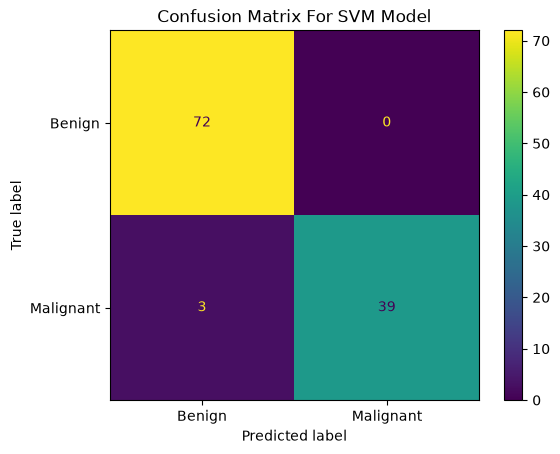

In [13]:
test_confusion_matrix = confusion_matrix(y_test, test_predictions)

disp_CM = ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=["Benign", "Malignant"]
)

disp_CM.plot()
plt.title("Confusion Matrix For SVM Model")
plt.show()